# Прогнозирование ценового сегмента автомобиля

ДЗ 1. Онищенко Геннадий 336883
Проблем на начальных этапах не возникло, датасет с автомобилями выбрал из kaggle так как на носу покупка авто, максимально эта тема сейчас интересна.

## 1. Постановка задачи

### 1.1 Бизнес-постановка задачи

**Контекст:** Крупный онлайн-маркетплейс по продаже подержанных автомобилей (аналог auto.ru, mobile.de) сталкивается с проблемой: продавцы и покупатели часто не могут адекватно оценить, является ли выставленный автомобиль дорогим или доступным. Это приводит к:
- завышению цен продавцами, что приводит к простою авто на содержании;
- занижению цен, продавцы теряют деньги;
- ошибочным рекомендациям пользователям.

Бизнес-задача: Разработать автоматический классификатор ценового сегмента автомобиля. Систему, которая по техническим характеристикам авто мгновенно определяет, относится ли он к дорогому сегменту (выше медианной цены рынка) или к доступному сегменту (ниже медианной цены).

Такой инструмент позволит:
- автоматически фильтровать объявления по ценовому сегменту;
- предупреждать продавцов о нерыночном ценообразовании;
- улучшить качество рекомендательной системы для покупателей.

### 1.2 ML-постановка задачи

Бизнес-задача формализуется как задача **бинарной классификации**:

- **Целевая переменная (target):** `Price_Segment`
  - `1` — автомобиль дорогой (цена **выше медианы** по датасету: ~46 112 $)
  - `0` — автомобиль доступный (цена **ниже или равна медиане**)

- **Признаки (features):** `Brand`, `Model_Year`, `Engine_Size`, `Fuel_Type`, `Transmission`, `Mileage`, `Doors`, `Owner_Count`, `Horsepower`

- **Тип задачи:** Supervised Learning, Binary Classification

- **Алгоритмы для исследования:** Logistic Regression (baseline), Random Forest, Gradient Boosting (XGBoost/LightGBM)

### 1.3 Описание датасета

Датасет содержит **2 000 записей** об автомобилях с 11 признаками:

| Признак | Тип | Описание |
|---|---|---|
| `Car_ID` | int | Уникальный идентификатор |
| `Brand` | str | Бренд (Ford, Hyundai, BMW, Honda, Tesla, Toyota) |
| `Model_Year` | int | Год выпуска (2005–2023) |
| `Engine_Size` | float | Объём двигателя (л) |
| `Fuel_Type` | str | Тип топлива (Diesel, Petrol, Electric, Hybrid) |
| `Transmission` | str | Тип КПП (Automatic / Manual) |
| `Mileage` | int | Пробег (км) |
| `Doors` | int | Количество дверей (2, 3, 4) |
| `Owner_Count` | int | Количество владельцев |
| `Horsepower` | int | Мощность двигателя (л.с.) |
| `Price` | float | Цена автомобиля ($) — **целевая переменная (исходная)** |

---
# 2. Выбор и обоснование метрики

### Выбранные метрики: **ROC-AUC** (основная) + **F1-Score** (вспомогательная)

**ROC-AUC** выбрана как основная метрика по следующим причинам:
1. Связь с бизнес-целью. Маркетплейс использует модель для ранжирования и рекомендаций. Мне важна именно способность разделять классы, а не конкретный порог. ROC-AUC оценивает качество ранжирования независимо от выбранного порога классификации.
2. Устойчивость к балансу классов. Целевая переменная формируется разбиением по медиане, что гарантирует близкое к 50/50 распределение — в этом случае ROC-AUC особенно информативен.
3. Стоимость ошибок симметрична. Ошибки первого рода (FP — дешёвый авто показан как дорогой) и второго рода (FN — дорогой авто занижен в сегменте) примерно одинаково вредны для пользователей платформы.

**F1-Score** используется как вспомогательная метрика для оценки при конкретном пороге классификации (0.5) и обеспечивает интерпретируемую оценку для продуктовой команды.

Если в будущем появится дисбаланс классов (например, при изменении разбивки на сегменты), то приоритет я отдам **PR-AUC** вместо ROC-AUC.

---
### 3. Разведочный анализ данных (EDA)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Настройки отображения
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
MEDIAN_PRICE_COLOR = '#e74c3c'
print('Библиотеки загружены')

Библиотеки загружены


### 3.1 Загрузка данных

In [6]:


df = pd.read_csv('car_price_dataset.csv')

print(f'Датасет загружен: {df.shape[0]:,} строк, {df.shape[1]} столбцов')
df.head()

Датасет загружен: 2,000 строк, 11 столбцов


,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.20,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.20,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.20,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.20,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.40,Electric,Manual,147233,3,4,290,38010.35


### 3.2 Базовые характеристики датасета

In [7]:
print('=== Типы данных и пропуски ===')
info_df = pd.DataFrame({
    'Тип': df.dtypes,
    'Пропуски': df.isnull().sum(),
    'Пропуски, %': (df.isnull().mean() * 100).round(2),
    'Уникальных': df.nunique()
})
print(info_df.to_string())

print()
print('Пропущенных значений нет, добработки по пропускам не требуется.')

=== Типы данных и пропуски ===
                  Тип  Пропуски  Пропуски, %  Уникальных
Car_ID          int64         0         0.00        2000
Brand          object         0         0.00           6
Model_Year      int64         0         0.00          19
Engine_Size   float64         0         0.00          41
Fuel_Type      object         0         0.00           4
Transmission   object         0         0.00           2
Mileage         int64         0         0.00        1989
Doors           int64         0         0.00           3
Owner_Count     int64         0         0.00           4
Horsepower      int64         0         0.00         329
Price         float64         0         0.00        1998

Пропущенных значений нет, добработки по пропускам не требуется.


In [8]:
print('=== Описательная статистика числовых признаков ===')
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

=== Описательная статистика числовых признаков ===


,count,mean,std,min,25%,50%,75%,max
Car_ID,2000.000000,1000.500000,577.494589,1.000000,500.750000,1000.500000,1500.250000,2000.000000
Model_Year,2000.000000,2013.963000,5.508248,2005.000000,2009.000000,2014.000000,2019.000000,2023.000000
Engine_Size,2000.000000,2.967550,1.146926,1.000000,2.000000,2.900000,4.000000,5.000000
Mileage,2000.000000,100736.956500,56002.915221,5036.000000,52365.500000,100590.500000,148024.500000,199904.000000
Doors,2000.000000,2.988000,0.818041,2.000000,2.000000,3.000000,4.000000,4.000000
Owner_Count,2000.000000,2.532500,1.125423,1.000000,2.000000,3.000000,4.000000,4.000000
Horsepower,2000.000000,235.709500,95.598110,70.000000,154.000000,236.000000,319.000000,399.000000
Price,2000.000000,46169.507675,9211.685713,18911.550000,39764.000000,46112.350000,52471.387500,72267.800000


In [19]:
# Создание целевой переменной
PRICE_MEDIAN = df['Price'].median()
df['Price_Segment'] = (df['Price'] > PRICE_MEDIAN).astype(int)

print(f'Медианная цена (порог разбиения): ${PRICE_MEDIAN:,.2f}')
print()
print('Распределение классов:')
seg_counts = df['Price_Segment'].value_counts()
for seg, cnt in seg_counts.items():
    label = 'Дорогой (>медианы)' if seg == 1 else 'Доступный (≤медианы)'
    print(f'  Класс {seg} [{label}]: {cnt} ({cnt/len(df)*100:.1f}%)')

print()
print('Распределение классов 50/50 — дисбаланса нет. ROC-AUC является корректной основной метрикой.')

Медианная цена (порог разбиения): $46,112.35

Распределение классов:
  Класс 0 [Доступный (≤медианы)]: 1000 (50.0%)
  Класс 1 [Дорогой (>медианы)]: 1000 (50.0%)

Распределение классов 50/50 — дисбаланса нет. ROC-AUC является корректной основной метрикой.


### 3.3 Визуализации

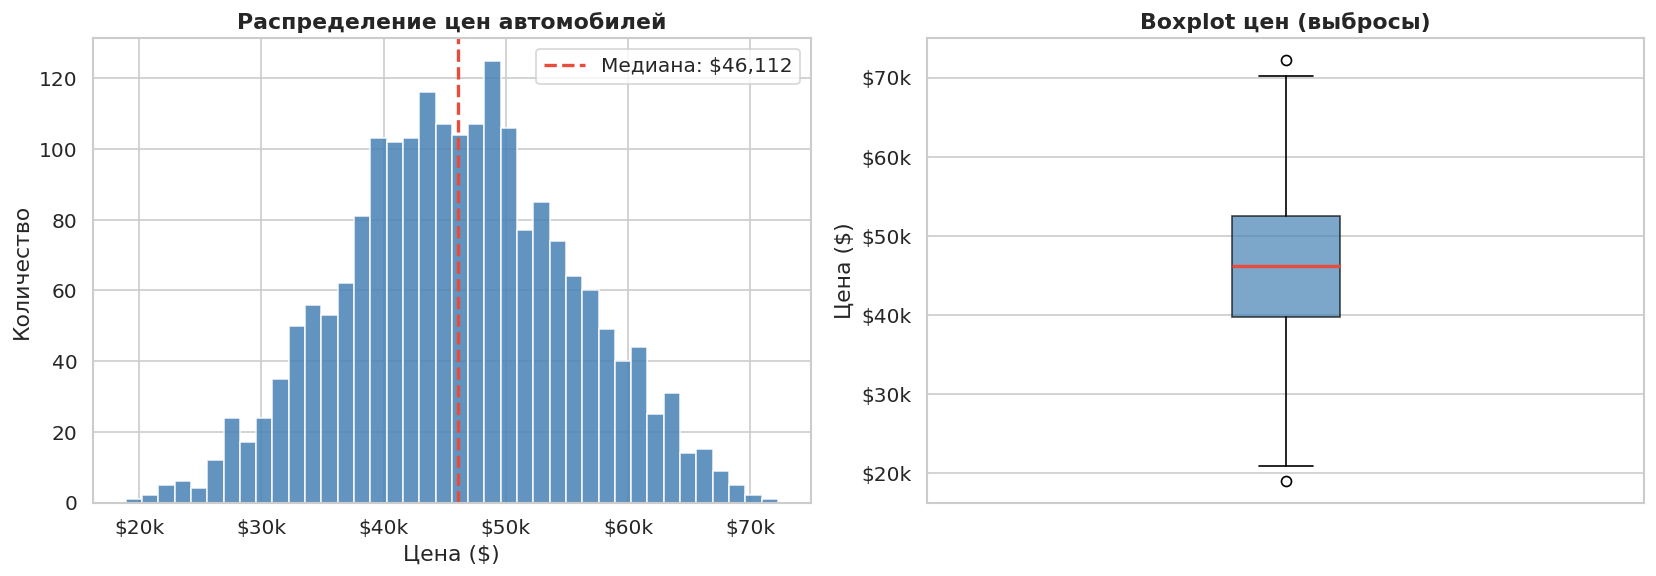


Распределение цен близко к нормальному с лёгким правым хвостом.
Диапазон цен широкий (~$19k–$72k), что говорит о разнообразии сегментов.
Выбросов по boxplot нет — экстремальных аномалий в данных не обнаружено.
Разбиение по медиане создаёт сбалансированные классы без дополнительной обработки.



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма цен
axes[0].hist(df['Price'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(PRICE_MEDIAN, color=MEDIAN_PRICE_COLOR, linestyle='--', linewidth=2, label=f'Медиана: ${PRICE_MEDIAN:,.0f}')
axes[0].set_title('Распределение цен автомобилей', fontweight='bold')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Количество')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Boxplot цен
axes[1].boxplot(df['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color=MEDIAN_PRICE_COLOR, linewidth=2))
axes[1].set_title('Boxplot цен (выбросы)', fontweight='bold')
axes[1].set_ylabel('Цена ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()

print('''
Распределение цен близко к нормальному с лёгким правым хвостом.
Диапазон цен широкий (~$19k–$72k), что говорит о разнообразии сегментов.
Выбросов по boxplot нет — экстремальных аномалий в данных не обнаружено.
Разбиение по медиане создаёт сбалансированные классы без дополнительной обработки.
''')

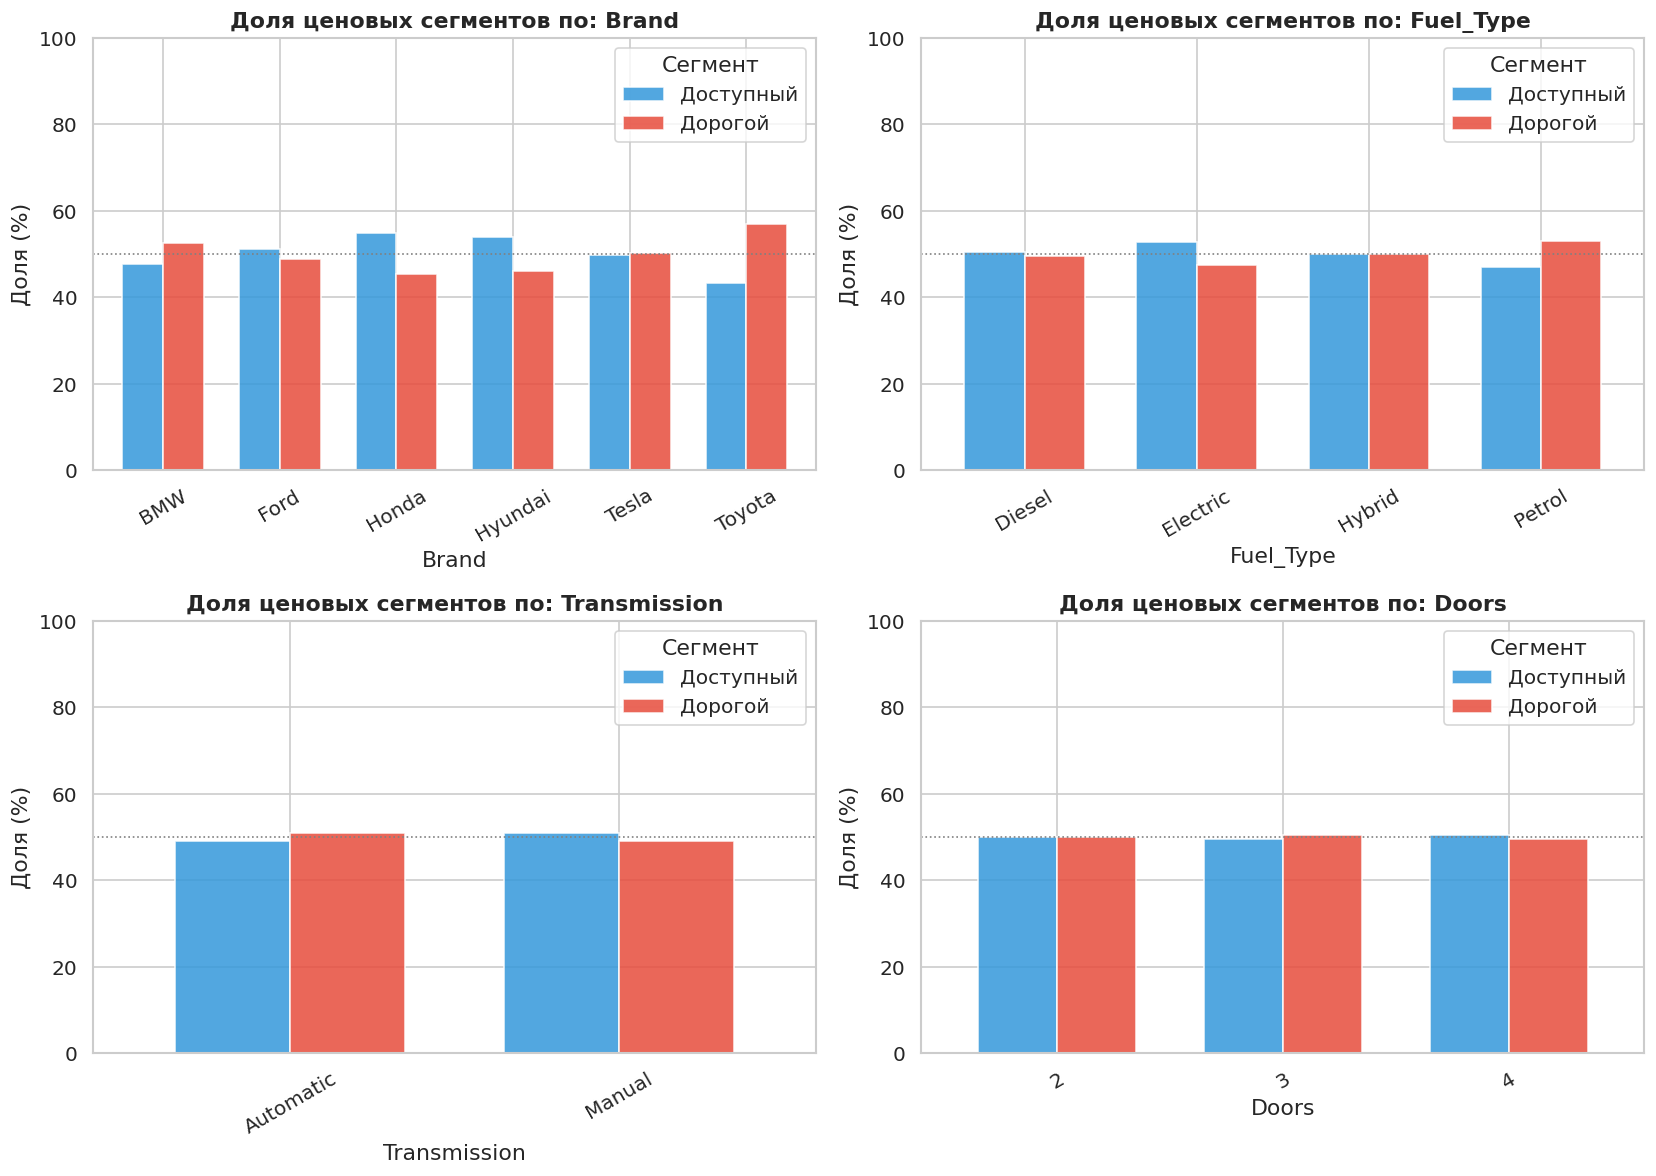


- Brand: BMW заметно чаще попадает в дорогой сегмент, Tesla и Honda — чаще в доступный.
  Это важный признак — бренд несёт сильный предсказательный сигнал.
- Fuel_Type: Electric и Hybrid чаще встречаются в доступном сегменте (возможно, это более новые авто с конкурентными ценами).
  Diesel и Petrol — более равномерны.
- Transmission и Doors: распределение близко к 50/50 в обоих классах — эти признаки могут быть слабо информативны.
  Тем не менее их стоит включить в модель и проверить через feature importance.



In [11]:
cat_cols = ['Brand', 'Fuel_Type', 'Transmission', 'Doors']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = {0: '#3498db', 1: '#e74c3c'}
labels = {0: 'Доступный', 1: 'Дорогой'}

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['Price_Segment'].value_counts(normalize=True).unstack().fillna(0) * 100
    ct.rename(columns=labels, inplace=True)
    ct[['Доступный', 'Дорогой']].plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'],
                                       edgecolor='white', width=0.7, alpha=0.85)
    axes[i].set_title(f'Доля ценовых сегментов по: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Доля (%)')
    axes[i].set_ylim(0, 100)
    axes[i].axhline(50, color='gray', linestyle=':', linewidth=1)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Сегмент')

plt.tight_layout()
plt.savefig('categorical_segments.png', bbox_inches='tight')
plt.show()

print('''
- Brand: BMW заметно чаще попадает в дорогой сегмент, Tesla и Honda — чаще в доступный.
  Это важный признак — бренд несёт сильный предсказательный сигнал.
- Fuel_Type: Electric и Hybrid чаще встречаются в доступном сегменте (возможно, это более новые авто с конкурентными ценами).
  Diesel и Petrol — более равномерны.
- Transmission и Doors: распределение близко к 50/50 в обоих классах — эти признаки могут быть слабо информативны.
  Тем не менее их стоит включить в модель и проверить через feature importance.
''')

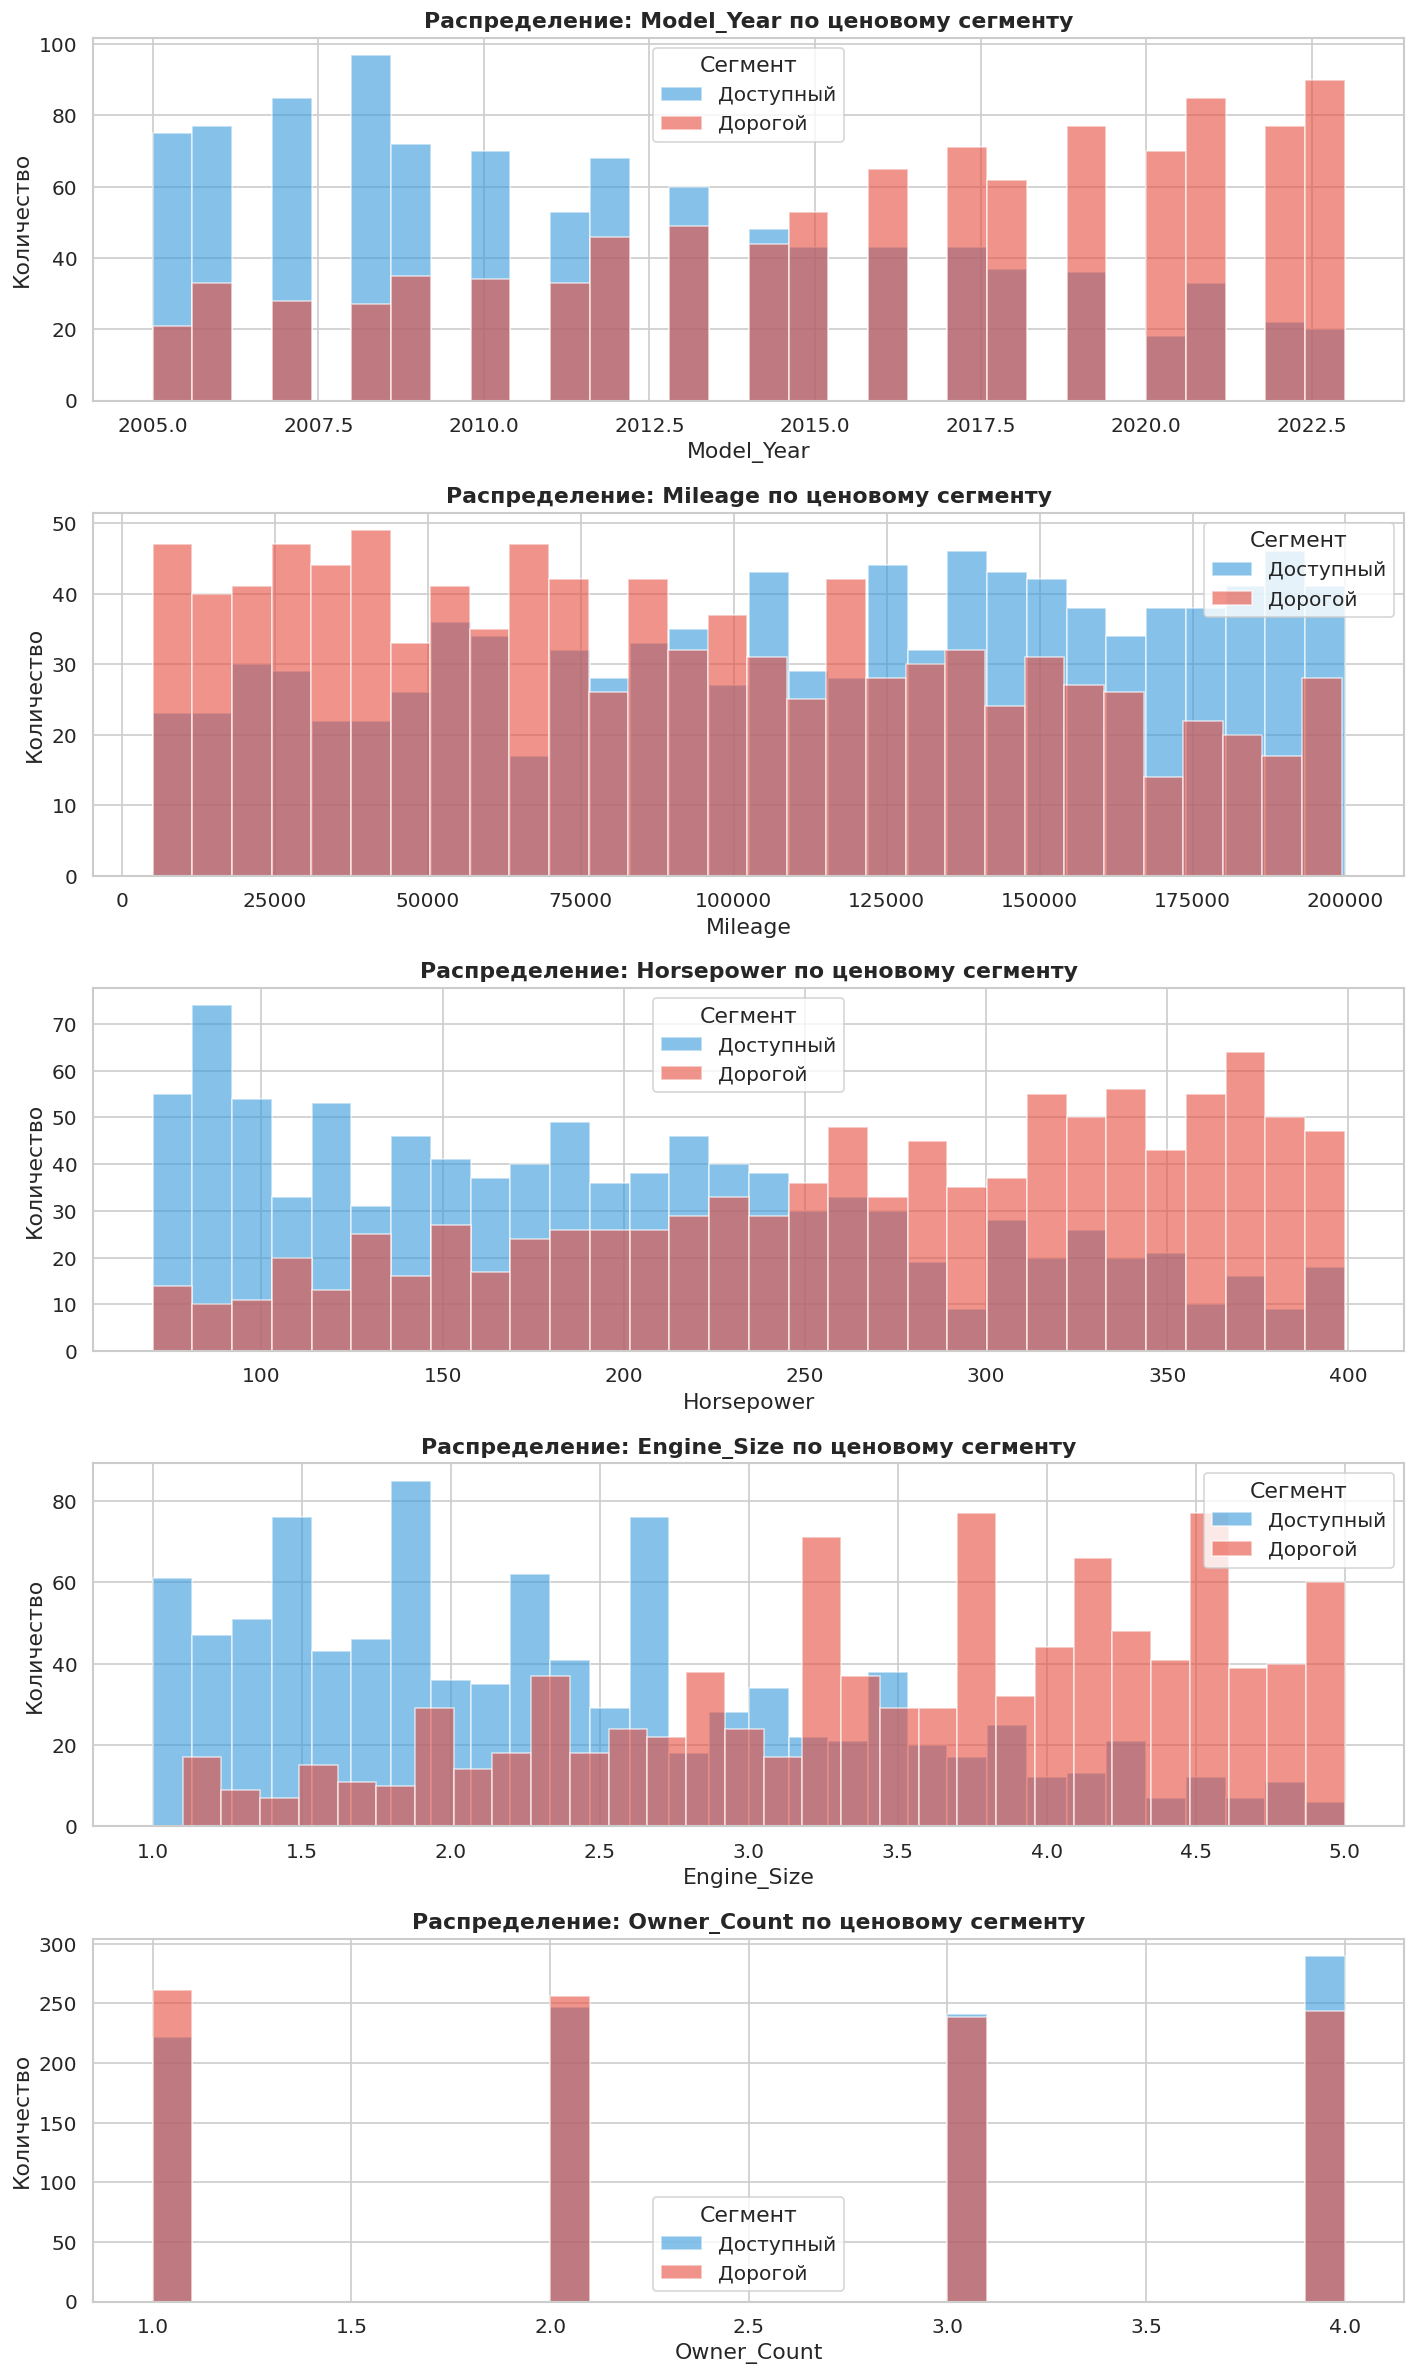


- Model_Year: Более новые авто (2015+) чаще дорогие — ожидаемо. Год выпуска — сильный признак.
- Mileage: Автомобили с меньшим пробегом чаще попадают в дорогой сегмент.
  Высокий пробег — маркер доступного сегмента. Возможна нелинейная зависимость.
- Horsepower: Дорогие авто в среднем мощнее. Распределения перекрываются, но центры смещены.
- Engine_Size: Похожая картина — дорогие авто имеют больший объём двигателя.
- Owner_Count: Авто с меньшим числом владельцев чаще дорогие. Это согласуется с логикой.

числовые признаки имеют разные масштабы — для Logistic Regression 
необходимо применить StandardScaler или MinMaxScaler. Для деревьев — нормировка не нужна.



In [12]:
num_cols = ['Model_Year', 'Mileage', 'Horsepower', 'Engine_Size', 'Owner_Count']
fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    for seg_val, color, label in [(0, '#3498db', 'Доступный'), (1, '#e74c3c', 'Дорогой')]:
        subset = df[df['Price_Segment'] == seg_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'Распределение: {col} по ценовому сегменту', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')
    axes[i].legend(title='Сегмент')

plt.tight_layout()
plt.savefig('numerical_distributions.png', bbox_inches='tight')
plt.show()

print('''
- Model_Year: Более новые авто (2015+) чаще дорогие — ожидаемо. Год выпуска — сильный признак.
- Mileage: Автомобили с меньшим пробегом чаще попадают в дорогой сегмент.
  Высокий пробег — маркер доступного сегмента. Возможна нелинейная зависимость.
- Horsepower: Дорогие авто в среднем мощнее. Распределения перекрываются, но центры смещены.
- Engine_Size: Похожая картина — дорогие авто имеют больший объём двигателя.
- Owner_Count: Авто с меньшим числом владельцев чаще дорогие. Это согласуется с логикой.

числовые признаки имеют разные масштабы — для Logistic Regression
необходимо применить StandardScaler или MinMaxScaler. Для деревьев — нормировка не нужна.
''')

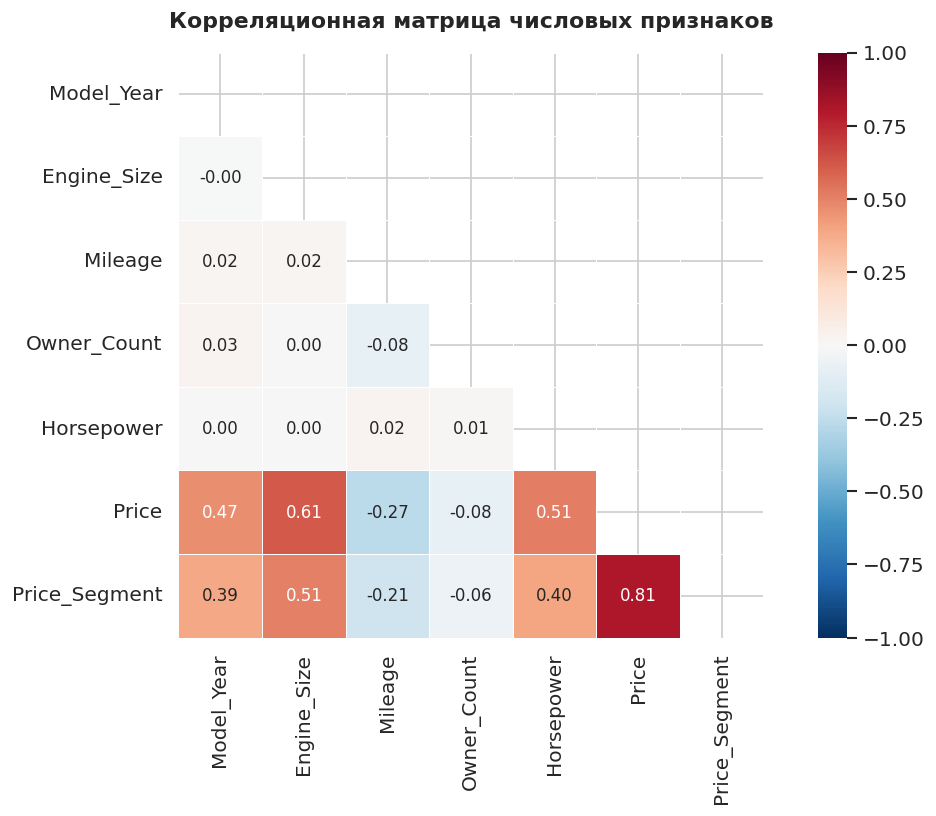


- Horsepower и Price_Segment: умеренная положительная корреляция — мощность влияет на сегмент.
- Mileage и Price_Segment: умеренная отрицательная — выше пробег → чаще доступный сегмент.
- Model_Year и Price_Segment: положительная — новее → дороже.
- Owner_Count и Price_Segment: небольшая отрицательная — больше владельцев → дешевле.
- Engine_Size и Horsepower: ожидаемая положительная корреляция между собой.

Engine_Size и Horsepower коррелируют умеренно — 
следует проверить VIF при использовании линейных моделей



In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

numeric_df = df[['Model_Year', 'Engine_Size', 'Mileage', 'Owner_Count', 'Horsepower', 'Price', 'Price_Segment']]
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 10}, linewidths=0.5)
ax.set_title('Корреляционная матрица числовых признаков', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('''
- Horsepower и Price_Segment: умеренная положительная корреляция — мощность влияет на сегмент.
- Mileage и Price_Segment: умеренная отрицательная — выше пробег → чаще доступный сегмент.
- Model_Year и Price_Segment: положительная — новее → дороже.
- Owner_Count и Price_Segment: небольшая отрицательная — больше владельцев → дешевле.
- Engine_Size и Horsepower: ожидаемая положительная корреляция между собой.

Engine_Size и Horsepower коррелируют умеренно —
следует проверить VIF при использовании линейных моделей
''')

/tmp/ipykernel_21924/150091768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Brand', y='Price', order=brand_order, ax=axes[0],


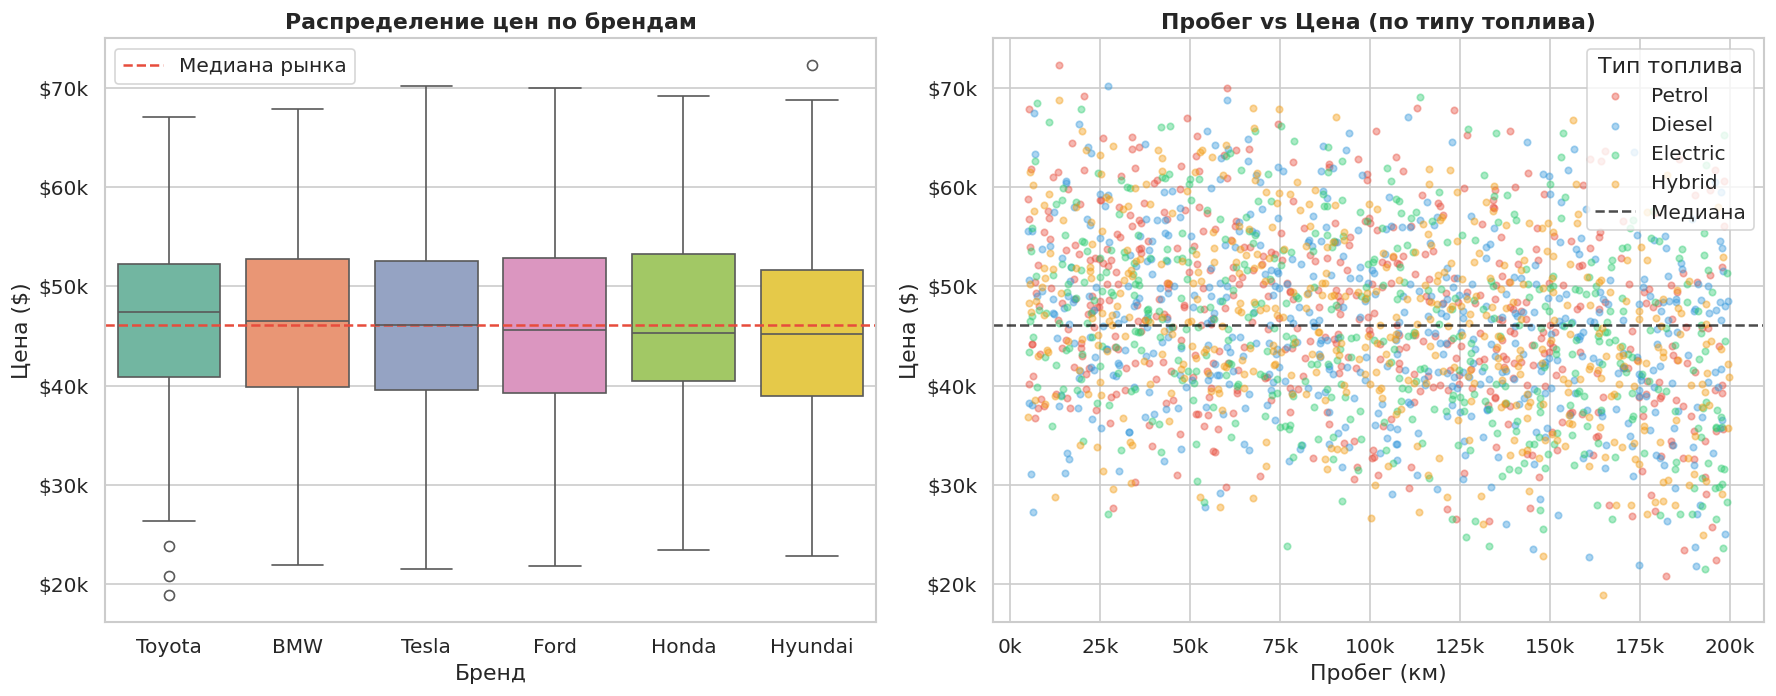


- BMW показывает наибольший разброс цен и наиболее смещён в дорогой сегмент.
- Tesla и Honda более сосредоточены в нижней части ценового диапазона.
- Scatter-plot: нет чёткой линейной зависимости пробег→цена по типу топлива, 
  что говорит о необходимости рассматривать взаимодействие признаков.
- Electric-автомобили распределены по всему диапазону цен — тип топлива сам по себе 
  не является достаточным предиктором.



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot цены по брендам
brand_order = df.groupby('Brand')['Price'].median().sort_values(ascending=False).index
df_plot = df.copy()
sns.boxplot(data=df_plot, x='Brand', y='Price', order=brand_order, ax=axes[0],
            palette='Set2')
axes[0].axhline(PRICE_MEDIAN, color=MEDIAN_PRICE_COLOR, linestyle='--', linewidth=1.5, label='Медиана рынка')
axes[0].set_title('Распределение цен по брендам', fontweight='bold')
axes[0].set_xlabel('Бренд')
axes[0].set_ylabel('Цена ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

# Scatter: Mileage vs Price по типу топлива
fuel_colors = {'Petrol': '#e74c3c', 'Diesel': '#3498db', 'Electric': '#2ecc71', 'Hybrid': '#f39c12'}
for fuel, color in fuel_colors.items():
    subset = df[df['Fuel_Type'] == fuel]
    axes[1].scatter(subset['Mileage'], subset['Price'], alpha=0.4, s=15, color=color, label=fuel)
axes[1].axhline(PRICE_MEDIAN, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Медиана')
axes[1].set_title('Пробег vs Цена (по типу топлива)', fontweight='bold')
axes[1].set_xlabel('Пробег (км)')
axes[1].set_ylabel('Цена ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].legend(title='Тип топлива')

plt.tight_layout()
plt.savefig('brand_mileage_price.png', bbox_inches='tight')
plt.show()

print('''
- BMW показывает наибольший разброс цен и наиболее смещён в дорогой сегмент.
- Tesla и Honda более сосредоточены в нижней части ценового диапазона.
- Scatter-plot: нет чёткой линейной зависимости пробег→цена по типу топлива,
  что говорит о необходимости рассматривать взаимодействие признаков.
- Electric-автомобили распределены по всему диапазону цен — тип топлива сам по себе
  не является достаточным предиктором.
''')

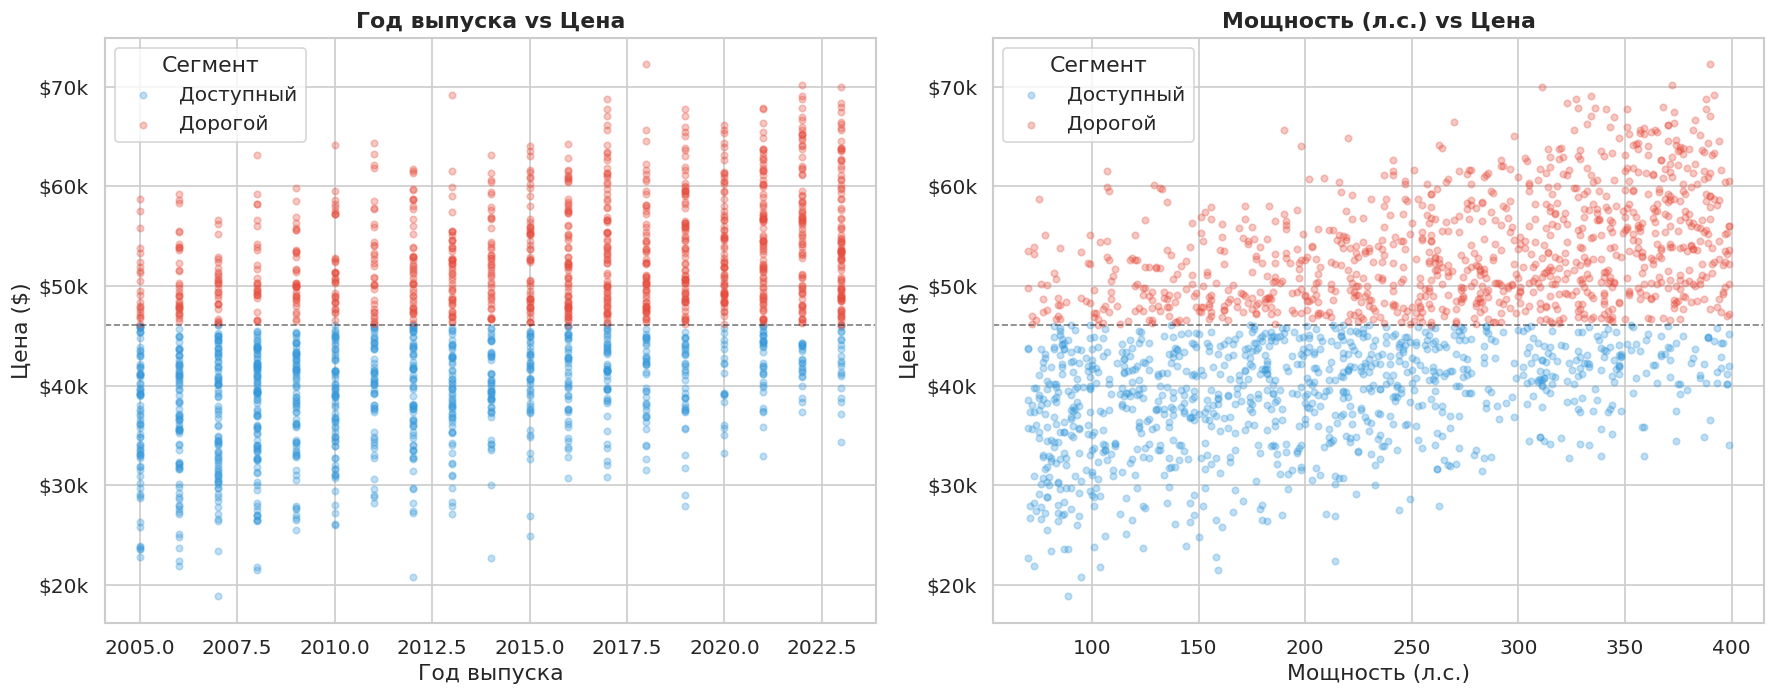


- Model_Year: Хорошая разделяемость классов — более свежие авто доминируют в дорогом сегменте.
  Однако есть пересечения: старые дорогие авто (возможно, коллекционные/спортивные).
- Horsepower: Видно разделение — дорогие авто концентрируются правее, 
  но граница нечёткая, что подтверждает необходимость использования нескольких признаков.

ни один числовой признак в одиночку не даёт чистого разделения — 
задача требует модели, учитывающей взаимодействие признаков (например, Gradient Boosting).



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Год выпуска vs Цена
for seg, color, label in [(0, '#3498db', 'Доступный'), (1, '#e74c3c', 'Дорогой')]:
    subset = df[df['Price_Segment'] == seg]
    axes[0].scatter(subset['Model_Year'], subset['Price'], alpha=0.3, s=15, color=color, label=label)
axes[0].set_title('Год выпуска vs Цена', fontweight='bold')
axes[0].set_xlabel('Год выпуска')
axes[0].set_ylabel('Цена ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend(title='Сегмент')
axes[0].axhline(PRICE_MEDIAN, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Horsepower vs Цена
for seg, color, label in [(0, '#3498db', 'Доступный'), (1, '#e74c3c', 'Дорогой')]:
    subset = df[df['Price_Segment'] == seg]
    axes[1].scatter(subset['Horsepower'], subset['Price'], alpha=0.3, s=15, color=color, label=label)
axes[1].set_title('Мощность (л.с.) vs Цена', fontweight='bold')
axes[1].set_xlabel('Мощность (л.с.)')
axes[1].set_ylabel('Цена ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].legend(title='Сегмент')
axes[1].axhline(PRICE_MEDIAN, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('year_hp_price.png', bbox_inches='tight')
plt.show()

print('''
- Model_Year: Хорошая разделяемость классов — более свежие авто доминируют в дорогом сегменте.
  Однако есть пересечения: старые дорогие авто (возможно, коллекционные/спортивные).
- Horsepower: Видно разделение — дорогие авто концентрируются правее,
  но граница нечёткая, что подтверждает необходимость использования нескольких признаков.

ни один числовой признак в одиночку не даёт чистого разделения —
задача требует модели, учитывающей взаимодействие признаков (например, Gradient Boosting).
''')

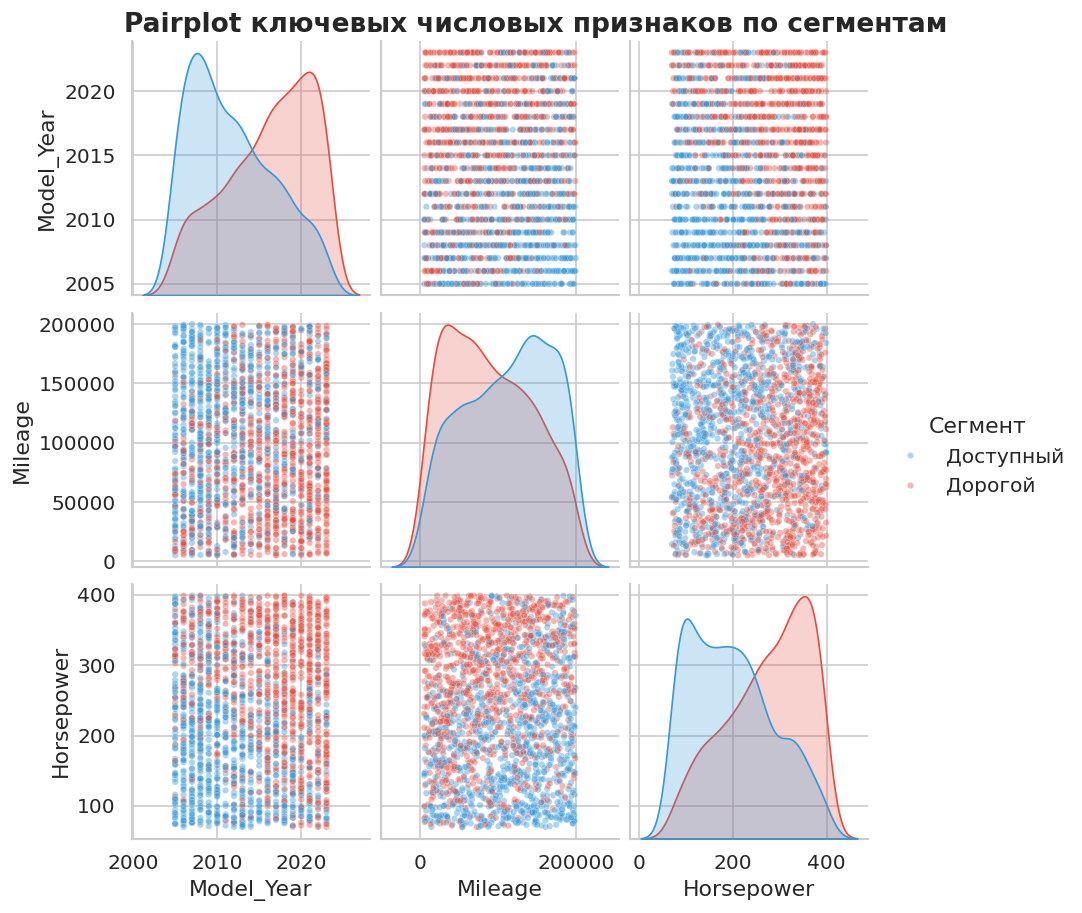


Pairplot демонстрирует:
1. Год выпуска и мощность вместе дают лучшее разделение классов, чем каждый по отдельности.
2. Mileage + Model_Year: чёткая диагональная граница — новые с малым пробегом = дорогие.
3. Классы перекрываются во всех проекциях — необходимы нелинейные методы классификации.



In [16]:
pair_cols = ['Model_Year', 'Mileage', 'Horsepower', 'Price_Segment']
pair_df = df[pair_cols].copy()
pair_df['Сегмент'] = pair_df['Price_Segment'].map({0: 'Доступный', 1: 'Дорогой'})

g = sns.pairplot(pair_df.drop('Price_Segment', axis=1),
                 hue='Сегмент', palette={'Доступный': '#3498db', 'Дорогой': '#e74c3c'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Pairplot ключевых числовых признаков по сегментам', y=1.01, fontweight='bold')
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()

print('''
Pairplot демонстрирует:
1. Год выпуска и мощность вместе дают лучшее разделение классов, чем каждый по отдельности.
2. Mileage + Model_Year: чёткая диагональная граница — новые с малым пробегом = дорогие.
3. Классы перекрываются во всех проекциях — необходимы нелинейные методы классификации.
''')

---
## 4. Итоги EDA

### Ключевые выводы:

| # | Наблюдение | Действие |
|---|---|---|
| 1 | **Пропусков нет** — данные чистые | Обработка пропусков не нужна |
| 2 | **Классы сбалансированы** (~50/50) | Oversampling/undersampling не требуется |
| 3 | **Числовые признаки разномасштабны** | Применить StandardScaler для линейных моделей |
| 4 | **Категориальные признаки** (Brand, Fuel_Type и др.) | Label Encoding / One-Hot Encoding |
| 5 | **Мультиколлинеарность** Engine_Size ↔ Horsepower | Проверить VIF, рассмотреть отбор признаков |
| 6 | **Нелинейные зависимости** (Mileage, Year) | Предпочесть tree-based модели |
| 7 | **Brand — сильный признак** | Обязательно включить, возможен target encoding |
| 8 | **Нет очевидных выбросов** | Дополнительная фильтрация не нужна |


In [17]:
print('=== ИТОГОВАЯ СВОДКА ДАТАСЕТА ===')
print(f'Строк:              {len(df):,}')
print(f'Признаков:          {df.shape[1] - 2} (без Car_ID и Price)')
print(f'Пропусков:          0')
print(f'Медиана цены:       ${PRICE_MEDIAN:,.2f}')
print(f'Класс 0 (доступный): {(df["Price_Segment"]==0).sum()} ({(df["Price_Segment"]==0).mean()*100:.1f}%)')
print(f'Класс 1 (дорогой):   {(df["Price_Segment"]==1).sum()} ({(df["Price_Segment"]==1).mean()*100:.1f}%)')
print(f'Брендов:            {df["Brand"].nunique()} ({list(df["Brand"].unique())})')
print(f'Типов топлива:      {df["Fuel_Type"].nunique()} ({list(df["Fuel_Type"].unique())})')


=== ИТОГОВАЯ СВОДКА ДАТАСЕТА ===
Строк:              2,000
Признаков:          10 (без Car_ID и Price)
Пропусков:          0
Медиана цены:       $46,112.35
Класс 0 (доступный): 1000 (50.0%)
Класс 1 (дорогой):   1000 (50.0%)
Брендов:            6 (['Ford', 'Hyundai', 'BMW', 'Honda', 'Tesla', 'Toyota'])
Типов топлива:      4 (['Hybrid', 'Electric', 'Diesel', 'Petrol'])


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
